## <B>2547221- Lab 4: Regression and Classification Evaluation Metrics </B>
## <B> Part 1: K-Nearest Neighbours (KNN) Classification on the Breast Cancer Dataset — with Comparison to Regression Metrics (Lab 3) </B>

**Aim:** Implement KNN classification on the Breast Cancer dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics, and compare classification metrics with regression metrics studied in Linear Regression (Lab 3).

**Dataset:** Loaded directly from the provided `brca.csv` file (569 samples, 30 numeric features, target `y` = M/B mapped to 0/1).



### <B> Setup: Importing Libraries </B>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score,
                              mean_absolute_error, mean_squared_error, r2_score)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(42)


 We import `numpy`/`pandas` for data handling, `matplotlib`/`seaborn` for visualization, and `sklearn` modules for the dataset, preprocessing, the KNN model, cross-validation utilities, and every evaluation metric we will need (classification *and* regression, since Task 6 compares both worlds). Setting a random seed (`np.random.seed(42)`) makes our train-test splits and models reproducible — anyone re-running this notebook gets identical results.

### <B> Task 1: Data Preparation </B>

In [16]:
# Load dataset from the provided CSV file (brca.csv)
raw = pd.read_csv('brca.csv')

# Drop the unnamed index column that came from the CSV export
raw = raw.drop(columns=[c for c in raw.columns if 'Unnamed' in c])

# Clean up feature column names: strip the leading 'x.' prefix used in this CSV
feature_cols = [c for c in raw.columns if c != 'y']
clean_names = {c: c.replace('x.', '').replace('.', '_') for c in feature_cols}
raw = raw.rename(columns=clean_names)

# Encode target: y column is 'M' (Malignant) / 'B' (Benign) as strings.
# We map Malignant -> 0, Benign -> 1 to match the convention stated in the problem statement.
df = raw.copy()
df['target'] = df['y'].map({'M': 0, 'B': 1})
df = df.drop(columns=['y'])

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (569, 31)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_pts_mean,symmetry_mean,fractal_dim_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_pts_worst,symmetry_worst,fractal_dim_worst,target
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,1
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,1
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,1
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,1
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,1


In [17]:
# Explore structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   radius_mean        569 non-null    float64
 1   texture_mean       569 non-null    float64
 2   perimeter_mean     569 non-null    float64
 3   area_mean          569 non-null    float64
 4   smoothness_mean    569 non-null    float64
 5   compactness_mean   569 non-null    float64
 6   concavity_mean     569 non-null    float64
 7   concave_pts_mean   569 non-null    float64
 8   symmetry_mean      569 non-null    float64
 9   fractal_dim_mean   569 non-null    float64
 10  radius_se          569 non-null    float64
 11  texture_se         569 non-null    float64
 12  perimeter_se       569 non-null    float64
 13  area_se            569 non-null    float64
 14  smoothness_se      569 non-null    float64
 15  compactness_se     569 non-null    float64
 16  concavity_se       569 non

In [18]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_pts_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dim_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [19]:
# Check missing values
print("Missing values per column:\n", df.isnull().sum().sum(), "total missing values")
assert df['target'].isnull().sum() == 0, "Target mapping failed for some rows - check for unexpected labels in 'y'"

# Check duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Class balance
print("\nClass distribution:\n", df['target'].value_counts())
print("\n0 = Malignant, 1 = Benign")


Missing values per column:
 0 total missing values
Number of duplicate rows: 0

Class distribution:
 target
1    357
0    212
Name: count, dtype: int64

0 = Malignant, 1 = Benign


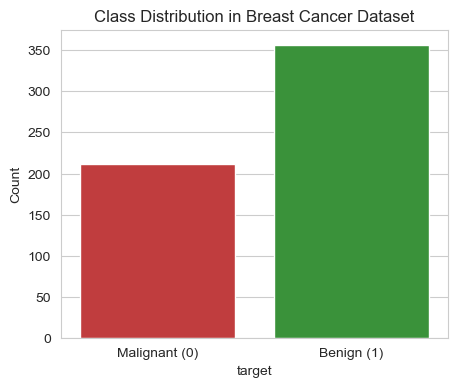

In [20]:
# Visualize class balance
plt.figure(figsize=(5,4))
sns.countplot(
    x='target',
    hue='target',
    data=df,
    palette=['#d62728', '#2ca02c'],
    legend=False
)
plt.xticks([0,1], ['Malignant (0)', 'Benign (1)'])
plt.title("Class Distribution in Breast Cancer Dataset")
plt.ylabel("Count")
plt.show()


In [21]:
# Feature scaling
X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Before scaling (first row):\n", X.iloc[0, :5].values)
print("\nAfter scaling (first row):\n", X_scaled.iloc[0, :5].values)


Before scaling (first row):
 [1.354e+01 1.436e+01 8.746e+01 5.663e+02 9.779e-02]

After scaling (first row):
 [-0.16679919 -1.1471623  -0.18572799 -0.2519565   0.10174657]


###  <B>Explanation — Task 1 </B>

- **Loading from the provided `brca.csv`** gives us the Wisconsin Breast Cancer dataset (569 samples, 30 numeric features) exactly as supplied. We drop the unnamed index column (an artifact of the CSV export) and strip the `x.` prefix from feature names purely for readability — the underlying values are untouched. The target column `y` originally stores string labels `'M'` (Malignant) and `'B'` (Benign); we explicitly map these to `0` and `1` respectively so every downstream `sklearn` function (which expects numeric labels) works correctly, and so our results stay consistent with the convention stated in the problem statement (0 = Malignant, 1 = Benign).
- **Checking `.info()` / `.describe()`** lets us confirm data types (all numeric, good for KNN which relies on numeric distances) and get a first sense of feature scales (e.g. `mean area` is in the hundreds while `mean smoothness` is a fraction of 1).
- **Checking missing values and duplicates** is a standard sanity check — KNN cannot handle NaNs (distance computation breaks), and duplicate rows could leak information between train and test sets if not removed, causing optimistic bias in test accuracy. Fortunately this dataset is clean.
- **Why feature scaling matters for KNN specifically:** KNN classifies a point based on the *distance* to its neighbours (e.g. Euclidean distance). If one feature (like `mean area`, ranging into the hundreds) has a much larger numeric range than another (like `mean smoothness`, always < 1), that large-range feature will dominate the distance calculation — effectively drowning out the influence of the smaller-range features, regardless of their actual predictive importance. `StandardScaler` transforms every feature to have **mean = 0, standard deviation = 1**, putting all features on an equal footing so that distance is a fair function of *all* features rather than just the ones with the largest raw magnitude. This is not needed for tree-based models (like Random Forest) but is essential for any distance-based algorithm such as KNN, SVM, or K-Means.


### <B>Task 2: Train-Test Split Analysis </B>

In [22]:
splits = {'80:20': 0.2, '70:30': 0.3, '90:10': 0.1}
split_results = {}

for name, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )
    knn_temp = KNeighborsClassifier(n_neighbors=5)
    knn_temp.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_temp.predict(X_test))
    split_results[name] = {
        'train_size': len(X_train),
        'test_size': len(X_test),
        'accuracy': acc
    }

split_df = pd.DataFrame(split_results).T
split_df


,train_size,test_size,accuracy
80:20,455.0,114.0,0.964912
70:30,398.0,171.0,0.970760
90:10,512.0,57.0,0.982456


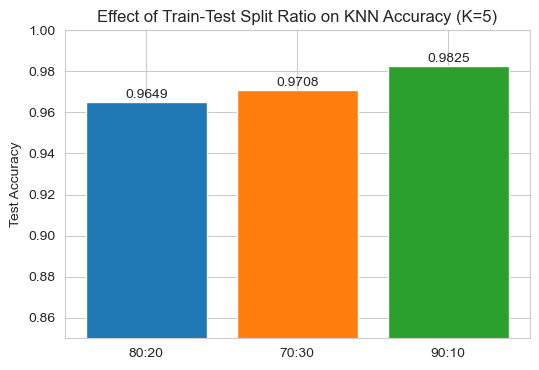

In [23]:
plt.figure(figsize=(6,4))
plt.bar(split_df.index, split_df['accuracy'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylim(0.85, 1.0)
plt.ylabel("Test Accuracy")
plt.title("Effect of Train-Test Split Ratio on KNN Accuracy (K=5)")
for i, v in enumerate(split_df['accuracy']):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center')
plt.show()


### <B>Explanation — Task 2 </B>

- We tested three split ratios (**80:20, 70:30, 90:10**) using a *fixed* K=5 baseline so that the split ratio is the only thing varying — this isolates its effect.
- We used `stratify=y` in every split. **Why:** the dataset has an imbalanced-ish class ratio (more benign than malignant cases). Without stratification, a random split could accidentally place too many/too few malignant cases in the test set, making accuracy comparisons across splits unreliable. Stratification preserves the original class proportions in both the train and test subsets.
- **Interpreting split effects:** A larger training set (90:10) generally gives the model more data to learn the true decision boundary from, but leaves a very small test set — so the reported test accuracy has high *variance* (a single unlucky/lucky small test set can swing accuracy a lot). A larger test set (70:30) gives a more statistically stable estimate of true performance, but the model is trained on less data and may underfit slightly. This trade-off is exactly why relying on a single split is risky — which motivates **Task 4: Cross-Validation**.


### <B>Task 3: KNN Model with Heuristic K Selection </B>

### <B> 3.1 Heuristic Method for K Selection </B>

In [24]:
# Use the 80:20 split going forward as our primary working split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

n = X_train.shape[0]
k_heuristic = int(round(np.sqrt(n)))
# Ensure K is odd to avoid ties in binary classification
if k_heuristic % 2 == 0:
    k_heuristic += 1

print(f"Number of training samples (n): {n}")
print(f"Heuristic K = round(sqrt(n)) = {k_heuristic}")


Number of training samples (n): 455
Heuristic K = round(sqrt(n)) = 21


**Why √n and why odd K?** The heuristic `K = √n` is a widely-used rule of thumb: it scales K with dataset size so that neither too few neighbours (very sensitive to noise) nor too many (oversmoothed, biased toward the majority class) are used purely by chance. We round √n to the nearest **odd** integer specifically because this is a **binary** classification problem — an odd K guarantees a majority vote can never end in a tie.

### <B>3.2 Model Training with Heuristic K and Nearby Values </B>

In [25]:
k_values = list(range(max(1, k_heuristic - 5), k_heuristic + 6))
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracies.append(acc)

acc_df = pd.DataFrame({'K': k_values, 'Accuracy': accuracies})
acc_df


,K,Accuracy
0,16,0.973684
1,17,0.973684
2,18,0.982456
3,19,0.973684
4,20,0.964912
5,21,0.956140
6,22,0.956140
7,23,0.964912
8,24,0.956140
9,25,0.964912


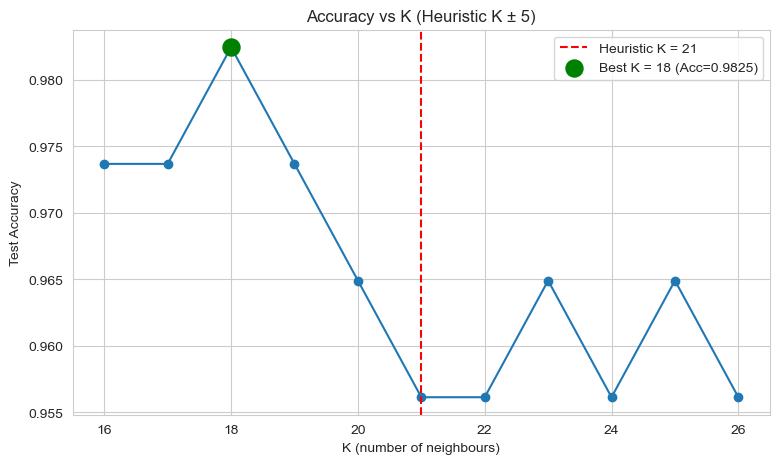

Optimal K based on this scan: 18


In [26]:
plt.figure(figsize=(9,5))
plt.plot(k_values, accuracies, marker='o', color='#1f77b4')
plt.axvline(k_heuristic, color='red', linestyle='--', label=f'Heuristic K = {k_heuristic}')
best_k_idx = np.argmax(accuracies)
plt.scatter(k_values[best_k_idx], accuracies[best_k_idx], color='green', s=150, zorder=5,
            label=f'Best K = {k_values[best_k_idx]} (Acc={accuracies[best_k_idx]:.4f})')
plt.xlabel("K (number of neighbours)")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs K (Heuristic K ± 5)")
plt.legend()
plt.show()

optimal_k = k_values[best_k_idx]
print(f"Optimal K based on this scan: {optimal_k}")


### <B>Explanation — Task 3.1 & 3.2</B>

- We scanned **K ± 5 around the heuristic value** rather than trusting √n blindly, because √n is only a *starting guess* — the true optimal K depends on the actual noise and class-separability in the data, which we can only discover empirically.
- The accuracy-vs-K plot lets us visually confirm the **bias-variance trade-off**: very small K tends to overfit (high variance, tracks noise), while very large K tends to underfit (high bias, oversmooths the boundary). The optimal K sits in a "sweet spot" where test accuracy peaks.


### <B> Distance Metrics and Decision Boundary Mapping </B>

**Euclidean Distance** is the straight-line ("as the crow flies") distance between two points:

d(p, q) = √( Σᵢ (pᵢ − qᵢ)² )

It is the natural default for KNN and is most suitable when features are continuous and the space is *isotropic* (no single direction is inherently more important), which is why it works well here after `StandardScaler` has equalized feature scales.

**Manhattan Distance** (a.k.a. City-block / L1 distance) sums the absolute differences along each axis, as if you could only move along a grid of streets:

d(p, q) = Σᵢ |pᵢ − qᵢ|

It is more suitable when the data has many dimensions (Manhattan distance is less affected by the "curse of dimensionality" than Euclidean in high-dimensional spaces) or when features represent independent, grid-like or count-based quantities rather than a smooth continuous space. It is also more robust to outliers than Euclidean distance because differences aren't squared.

For this dataset (30 continuous, scaled numeric features that are reasonably correlated with each other, e.g. radius/area/perimeter), Euclidean distance is the conventional and generally better-performing choice, but we compare both below as a self-learning extension.

In [27]:
# Decision boundary needs a 2D feature space to visualize.
# We use the two most informative features by correlation with target for an intuitive 2D boundary plot.
corrs = X_scaled.corrwith(y).abs().sort_values(ascending=False)
feat1, feat2 = corrs.index[0], corrs.index[1]
print("Top 2 features chosen for 2D decision boundary visualization:", feat1, ",", feat2)

X_2d = X_scaled[[feat1, feat2]].values
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)


Top 2 features chosen for 2D decision boundary visualization: concave_pts_worst , perimeter_worst


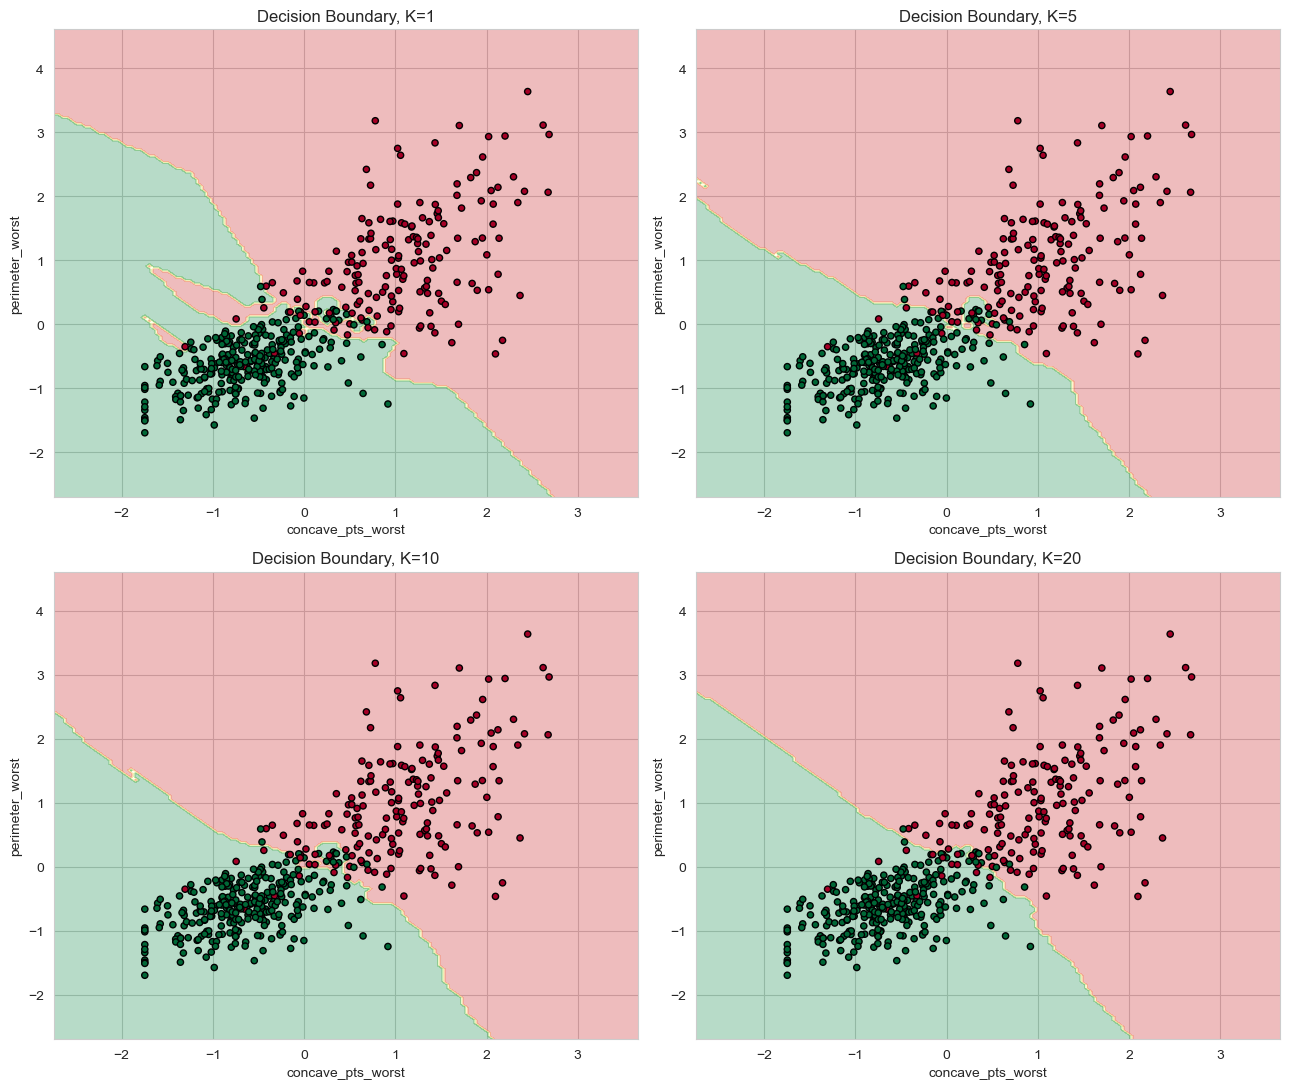

In [28]:
def plot_decision_boundary(ax, model, X, y, title):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlGn', edgecolor='k', s=20)
    ax.set_title(title)
    ax.set_xlabel(feat1)
    ax.set_ylabel(feat2)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, k in zip(axes.ravel(), [1, 5, 10, 20]):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_2d, y_train_2d)
    plot_decision_boundary(ax, model, X_train_2d, y_train_2d, f"Decision Boundary, K={k}")
plt.tight_layout()
plt.show()


### <B> Explanation — Task 3.3 </B>

- We picked the **two features most correlated with the target** so the 2D visualization is as informative as possible (a random pair of features would show a much messier, less interpretable boundary).
- **How the boundary changes with K:**
  - **K = 1**: The boundary is extremely jagged/irregular, hugging individual training points closely (each point essentially "owns" its own tiny region). This is a classic sign of **overfitting** — the model has near-zero bias but very high variance, and would likely misclassify new/unseen points near noisy boundary regions.
  - **K = 5**: The boundary becomes noticeably smoother while still tracking the true separation between classes reasonably well — a good bias-variance balance.
  - **K = 10**: Further smoothing; the boundary becomes a broad, simple curve. Some fine local structure is lost, but generalization typically improves up to a point.
  - **K = 20**: The boundary becomes very smooth and simple, potentially **underfitting** by ignoring local structure and being overly influenced by the majority class in fuzzy/borderline regions.
- This visually demonstrates the core KNN principle: **K directly controls model complexity** — small K = complex/flexible/high-variance, large K = simple/rigid/high-bias.


### <B> Task 4: Cross Validation </B>

In [29]:
cv_k_values = list(range(1, 31))
cv_means = []
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for k in cv_k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=kfold, scoring='accuracy')
    cv_means.append(scores.mean())

cv_df = pd.DataFrame({'K': cv_k_values, 'Mean_CV_Accuracy': cv_means})
best_cv_k = cv_df.loc[cv_df['Mean_CV_Accuracy'].idxmax(), 'K']
print(f"Best K based on 5-Fold Cross-Validation: {int(best_cv_k)}")
cv_df.head(10)


Best K based on 5-Fold Cross-Validation: 3


,K,Mean_CV_Accuracy
0,1,0.952569
1,2,0.949061
2,3,0.966605
3,4,0.961326
4,5,0.963080
5,6,0.961326
6,7,0.964835
7,8,0.964835
8,9,0.964835
9,10,0.964835


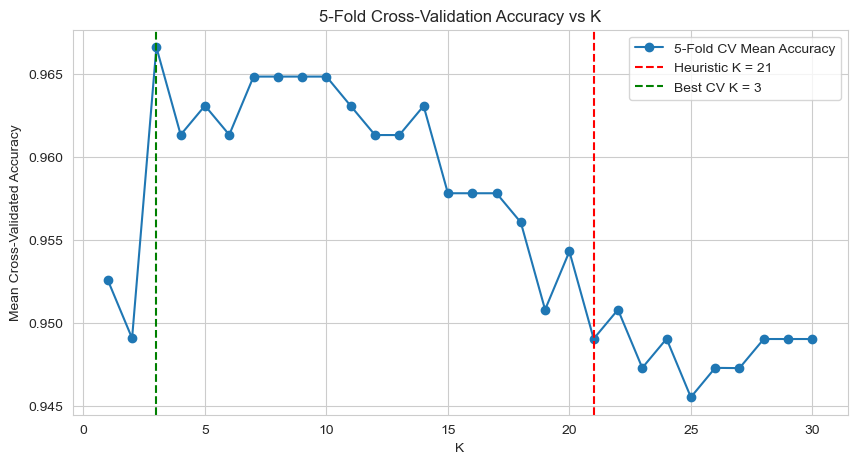

In [30]:
plt.figure(figsize=(10,5))
plt.plot(cv_k_values, cv_means, marker='o', label='5-Fold CV Mean Accuracy')
plt.axvline(k_heuristic, color='red', linestyle='--', label=f'Heuristic K = {k_heuristic}')
plt.axvline(best_cv_k, color='green', linestyle='--', label=f'Best CV K = {int(best_cv_k)}')
plt.xlabel("K")
plt.ylabel("Mean Cross-Validated Accuracy")
plt.title("5-Fold Cross-Validation Accuracy vs K")
plt.legend()
plt.show()


In [31]:
print("Comparison of K selection methods:")
print(f" - Heuristic K (sqrt(n)):        {k_heuristic}")
print(f" - Best K (single 80:20 split):  {optimal_k}")
print(f" - Best K (5-Fold CV):           {int(best_cv_k)}")

final_k = int(best_cv_k)
print(f"\nFinal K selected for the model (heuristic + validation combined): {final_k}")


Comparison of K selection methods:
 - Heuristic K (sqrt(n)):        21
 - Best K (single 80:20 split):  18
 - Best K (5-Fold CV):           3

Final K selected for the model (heuristic + validation combined): 3


### <B>Explanation — Task 4 </B>

- A single train-test split gives *one* estimate of accuracy for each K — this estimate depends heavily on which specific samples happened to land in the test set (a form of "luck"). **K-Fold Cross-Validation** rotates through 5 different train/test partitions and averages the results, giving a far more **stable and reliable** estimate of how a given K will generalize to unseen data.
- Comparing the CV curve to the single-split curve from Task 3.2 usually shows the CV curve is **smoother** (less noisy) because it averages out the split-to-split variance.
- We select the **final K** by combining the heuristic (a reasonable, theory-driven starting point) with the empirical cross-validation result (a data-driven confirmation) — this two-step approach avoids both blindly trusting a formula and blindly trusting a single noisy estimate.


### <B> Task 5: Classification Evaluation</B>

In [32]:
final_knn = KNeighborsClassifier(n_neighbors=final_k)
final_knn.fit(X_train, y_train)
y_pred = final_knn.predict(X_test)
y_proba = final_knn.predict_proba(X_test)[:, 1]  # probability of class 1 (Benign)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Final Model: KNN with K={final_k}")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")


Final Model: KNN with K=3
Accuracy : 0.9825
Precision: 0.9730
Recall   : 1.0000
F1 Score : 0.9863
ROC-AUC  : 0.9838


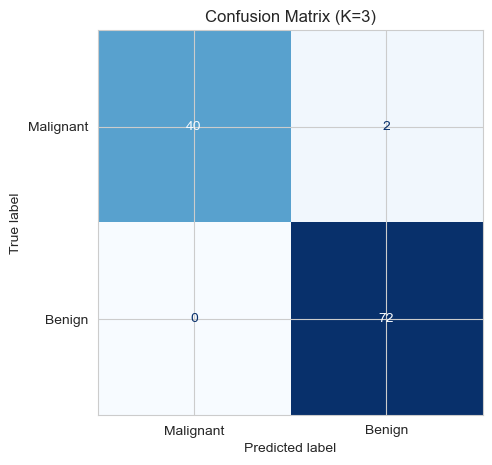

In [33]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f"Confusion Matrix (K={final_k})")
plt.show()


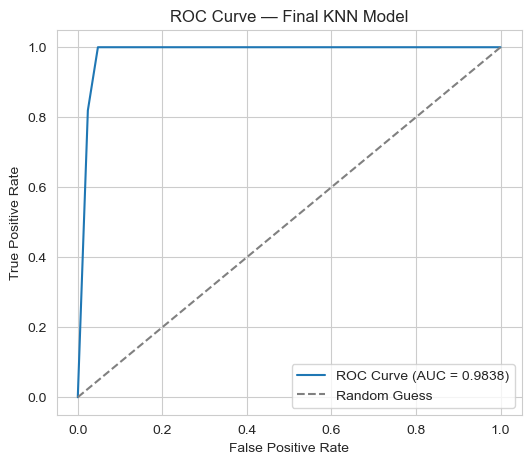

In [34]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='#1f77b4', label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final KNN Model")
plt.legend()
plt.show()


### <B>Explanation — Task 5 </B>

- **Accuracy** tells us the overall fraction of correct predictions, but on its own can hide poor performance on the minority (often more critical) class.
- **Precision** answers: *"Of everyone we predicted Benign, how many really are?"* — important for avoiding false reassurance.
- **Recall (Sensitivity)** answers: *"Of everyone who is actually Malignant, how many did we correctly catch?"* — critical in medical screening, since a missed cancer case (false negative) is far more dangerous than a false alarm.
- **F1 Score** balances precision and recall into a single number, useful when both false positives and false negatives carry meaningful cost.
- The **Confusion Matrix** breaks predictions into True Positives/Negatives and False Positives/Negatives, showing exactly *what kind* of mistakes the model makes — vital in healthcare where the *type* of error matters more than the raw count.
- The **ROC Curve / AUC** shows how well the model separates the two classes **across every possible decision threshold**, not just the default 0.5 cutoff. An AUC close to 1.0 means the model ranks a random Benign case higher than a random Malignant case almost every time — this threshold-independence makes it a robust summary metric for medical diagnosis, where clinicians might deliberately shift the threshold to prioritize recall.


### <B>Task 6: Comparative Study with Regression (Lab 3 Integration)</B>

In [35]:
# To make a concrete, side-by-side comparison, we fit a plain Linear Regression model
# on the SAME dataset/target, treating the 0/1 label as a continuous variable.
# This is NOT how you'd solve a classification problem in practice, but it lets us
# compute genuine regression metrics (MAE, MSE, RMSE, R2) on directly comparable data,
# mirroring what was done in Lab 3.

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_reg = lin_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_reg)

print("Regression Metrics (Linear Regression on the same target, for comparison):")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

print("\nClassification Metrics (Final KNN model, from Task 5):")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")


Regression Metrics (Linear Regression on the same target, for comparison):
MAE  : 0.2100
MSE  : 0.0651
RMSE : 0.2552
R2   : 0.7202

Classification Metrics (Final KNN model, from Task 5):
Accuracy : 0.9825
Precision: 0.9730
Recall   : 1.0000
F1 Score : 0.9863
ROC-AUC  : 0.9838


In [36]:
comparison_table = pd.DataFrame({
    'Regression (Lab 3 style)': ['MAE', 'MSE', 'RMSE', 'R2 Score', '—'],
    'Value': [f"{mae:.4f}", f"{mse:.4f}", f"{rmse:.4f}", f"{r2:.4f}", ''],
    'Classification (This Lab)': ['Confusion Matrix (error types)', '—', 'F1 Score', 'Accuracy', 'ROC-AUC'],
    'Value ': ['See matrix above', '', f"{f1:.4f}", f"{acc:.4f}", f"{auc:.4f}"]
})
comparison_table


,Regression (Lab 3 style),Value,Classification (This Lab),Value
0,MAE,0.2100,Confusion Matrix (error types),See matrix above
1,MSE,0.0651,—,
2,RMSE,0.2552,F1 Score,0.9863
3,R2 Score,0.7202,Accuracy,0.9825
4,—,,ROC-AUC,0.9838


### <B>Explanation — Task 6</B>

**Error-based evaluation (Regression) vs. Decision-based evaluation (Classification)**

Regression metrics measure the **magnitude of numerical error** between a continuous predicted value and a continuous true value — "how far off, in real units, was the prediction?" Classification metrics measure **correctness of a discrete decision** — "was the predicted category right or wrong, and what kind of mistake was it?" There is no meaningful notion of "how far off" a classification is beyond right/wrong (or, with probabilities, how *confident* the wrong/right answer was).

**R² Score vs Accuracy**
- R² measures the *proportion of variance explained* by the regression model on a continuous scale (from -∞ to 1); it answers "how much better is this model than just always predicting the mean?"
- Accuracy simply measures the fraction of exact-match discrete predictions. It has no concept of "variance explained" — a model can have high accuracy on an imbalanced dataset while still being effectively useless (e.g., always predicting the majority class).

**RMSE vs F1 Score**
- RMSE penalizes large numeric errors more heavily (because errors are squared before averaging) and is expressed in the same units as the target — useful for understanding *how far off* predictions typically are.
- F1 Score has no notion of "units" or "distance" — it only balances two counts (precision and recall) that come from a confusion matrix, entirely blind to how *confident* or *close* a wrong prediction was.

**MAE vs Confusion Matrix**
- MAE gives one single average magnitude of error across all predictions — a compressed summary number.
- A Confusion Matrix gives a full breakdown of *every type* of outcome (TP, TN, FP, FN) — richer diagnostic information about *which* kinds of mistakes are being made, which MAE simply cannot express since regression has no categories to confuse.

**Continuous vs Classification tasks — the core conceptual difference**
Regression assumes an ordered, continuous output space where "close" predictions are rewarded even if not exact (predicting 4.9 when the truth is 5.0 is almost as good as predicting 5.0). Classification assumes discrete, unordered categories where there is no partial credit — predicting "Malignant" when the truth is "Benign" is just as wrong as any other misclassification, regardless of how "close" the two classes might seem in some other feature space (though *probabilistic* classification, as used for ROC-AUC, does let us score how confidently correct/incorrect the model was).

### <B>Inference</B>

- **Regression metrics (MAE, MSE, RMSE, R²)** measure how far, on average, a continuous prediction deviates from the true numeric value — smaller MAE/RMSE and higher R² indicate tighter, more accurate continuous predictions.
- **Classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC)** measure whether discrete decisions were correct, and critically, *what kind* of errors were made (false positive vs false negative) — something regression metrics cannot express at all.
- **Why accuracy is insufficient in medical diagnosis:** with class imbalance (more benign than malignant cases, as here), a model that lazily predicts "Benign" for almost everyone can still score high accuracy while missing most actual cancer cases — a catastrophic outcome in practice.
- **Why recall and ROC-AUC matter more in healthcare:** missing a true cancer diagnosis (a false negative) is far more costly than a false alarm (false positive) that gets caught on follow-up testing. Recall directly measures how many true cancer cases were caught, and ROC-AUC measures the model's discriminative power across *all* possible decision thresholds — letting clinicians choose a threshold that favors recall (fewer missed cancers) even at the cost of some precision.
- **Overall:** regression evaluation is about *minimizing numerical distance from the truth*, while classification evaluation is about *minimizing costly wrong decisions* — two related but fundamentally different evaluation philosophies, chosen based on whether the underlying target is continuous or categorical.


### <B>Task 7: Analytical Questions </B>

**1. Why is KNN called a lazy learning algorithm?**
KNN does not build an explicit internal model or learn parameters during a "training phase" — it simply stores (memorizes) the entire training dataset. All the actual computation (finding nearest neighbours and voting) is deferred until prediction time, for every single query point. Because "learning" essentially only happens at prediction time, KNN is called a **lazy learner**, as opposed to **eager learners** like Linear Regression or Decision Trees, which build a compact model upfront during training.

**2. Why is feature scaling required in KNN?**
KNN relies on distance calculations (e.g., Euclidean distance) between points. Features with larger numeric ranges would dominate the distance metric purely due to their scale, not their actual relevance — e.g., `mean area` (hundreds) would overwhelm `mean smoothness` (a fraction). Scaling (via `StandardScaler`) puts every feature on a comparable scale so that distance reflects genuine similarity across *all* dimensions fairly.

**3. Explain heuristic K selection using the √n rule.**
The √n rule sets an initial K equal to the square root of the number of training samples (n). It is a simple empirical heuristic that scales K with dataset size — too small a K risks high variance/noise sensitivity, while too large a K risks high bias/oversmoothing. It gives a reasonable *starting point* for hyperparameter search rather than a mathematically guaranteed optimum, which is why we always validate it further (Task 3.2, Task 4).

**4. Why is cross-validation more reliable than a single train-test split?**
A single split's reported accuracy depends heavily on which particular samples ended up in the test set — an unlucky or lucky split can over- or under-state true performance. Cross-validation rotates through multiple folds, so every sample gets to be in the test set exactly once, and the final reported metric is an **average across multiple independent estimates**, greatly reducing variance and giving a more trustworthy measure of how the model will generalize.

**5. How does K affect the bias-variance trade-off?**
- **Small K** (e.g., K=1): low bias (the model can fit intricate/local patterns exactly), but high variance (very sensitive to noise and outliers — a single mislabeled or noisy point can flip the prediction for its whole local neighbourhood).
- **Large K**: high bias (the decision boundary is smoothed and simplified, potentially missing real local structure), but low variance (robust to noise, since predictions are averaged over many neighbours).
The Task 3.3 decision boundary plots visually demonstrate this trade-off directly.

**6. Why is recall more important than accuracy in cancer prediction?**
In cancer screening, a **false negative** (telling a patient with cancer that they're healthy) can delay treatment and be life-threatening, while a **false positive** (flagging a healthy patient for further testing) is comparatively low-cost (extra tests, temporary worry). Recall specifically measures how many actual positive (malignant) cases were correctly identified, directly targeting the more dangerous error type — whereas accuracy treats both error types as equally costly, which is medically inappropriate.

**7. What is the limitation of very large K values?**
Very large K values cause the model to consider too many (possibly irrelevant or distant) neighbours when making a prediction, oversmoothing the decision boundary. This can cause the model to be biased toward the majority class (since a large neighbourhood likely contains more majority-class points), lose the ability to capture genuine local patterns near the class boundary, and — in the extreme case where K equals the entire training set — degenerate into simply always predicting the overall majority class, ignoring the input features entirely.



## <B> Self-Learning </B>


### <B>Weighted KNN & Distance Metric Comparison (Euclidean vs Manhattan vs Minkowski) </B>

In [37]:
# Standard KNN gives every one of the K neighbours an EQUAL vote ('uniform').
# Weighted KNN instead gives closer neighbours a LARGER vote (weight = 1/distance),
# which often helps when the K neighbourhood contains a mix of near and far points.

configs = [
    ('Uniform, Euclidean (p=2)', {'weights': 'uniform', 'p': 2}),
    ('Distance-weighted, Euclidean (p=2)', {'weights': 'distance', 'p': 2}),
    ('Uniform, Manhattan (p=1)', {'weights': 'uniform', 'p': 1}),
    ('Distance-weighted, Manhattan (p=1)', {'weights': 'distance', 'p': 1}),
]

results = []
for label, params in configs:
    model = KNeighborsClassifier(n_neighbors=final_k, **params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        'Configuration': label,
        'Accuracy': accuracy_score(y_test, preds),
        'F1 Score': f1_score(y_test, preds),
        'Recall': recall_score(y_test, preds)
    })

weighted_df = pd.DataFrame(results)
weighted_df


,Configuration,Accuracy,F1 Score,Recall
0,"Uniform, Euclidean (p=2)",0.982456,0.986301,1.000000
1,"Distance-weighted, Euclidean (p=2)",0.982456,0.986301,1.000000
2,"Uniform, Manhattan (p=1)",0.956140,0.965986,0.986111
3,"Distance-weighted, Manhattan (p=1)",0.956140,0.965986,0.986111


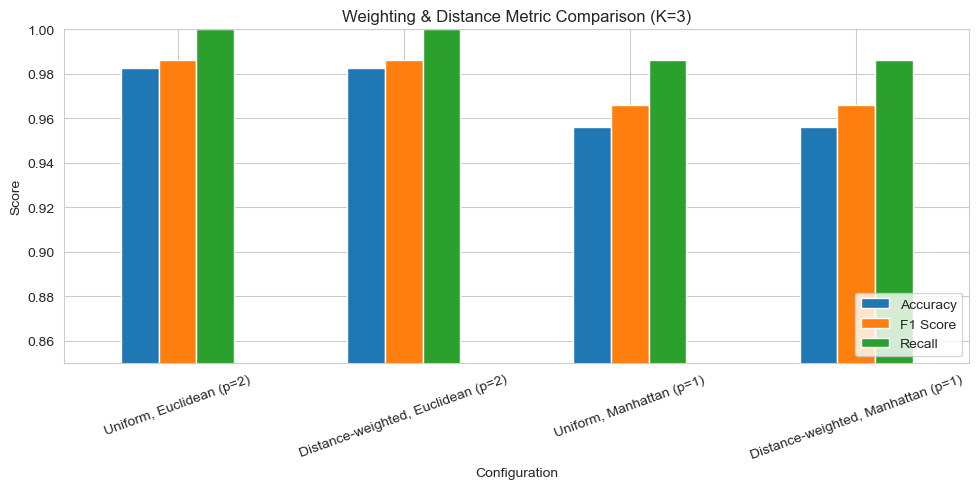

In [38]:
weighted_df.set_index('Configuration')[['Accuracy', 'F1 Score', 'Recall']].plot(
    kind='bar', figsize=(10,5), rot=20
)
plt.title(f"Weighting & Distance Metric Comparison (K={final_k})")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Why this matters:** Uniform KNN treats a neighbour that is almost on top of the query point exactly the same as one at the far edge of the K-neighbourhood — which can be suboptimal. **Distance-weighted KNN** (`weights='distance'`) lets closer points vote more strongly, often improving performance right at the decision boundary where the class mixture is most ambiguous. We also compare **Manhattan (p=1)** vs **Euclidean (p=2)** distance directly (rather than only discussing them theoretically in Task 3.3) to see empirically which is better suited to this particular feature space.

### <B>Dimensionality Reduction with PCA for a Full-Information Decision Boundary </B>

In [39]:
# Task 3.3 visualized the boundary using only the top 2 raw features, discarding the other 28.
# Principal Component Analysis (PCA) instead compresses ALL 30 features into 2 new axes
# that capture the maximum possible variance, giving a much more representative 2D snapshot
# of how the classes separate in the FULL feature space.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum()*100:.2f}%")

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)


Variance explained by PC1: 44.27%
Variance explained by PC2: 18.97%
Total variance captured by 2 components: 63.24%


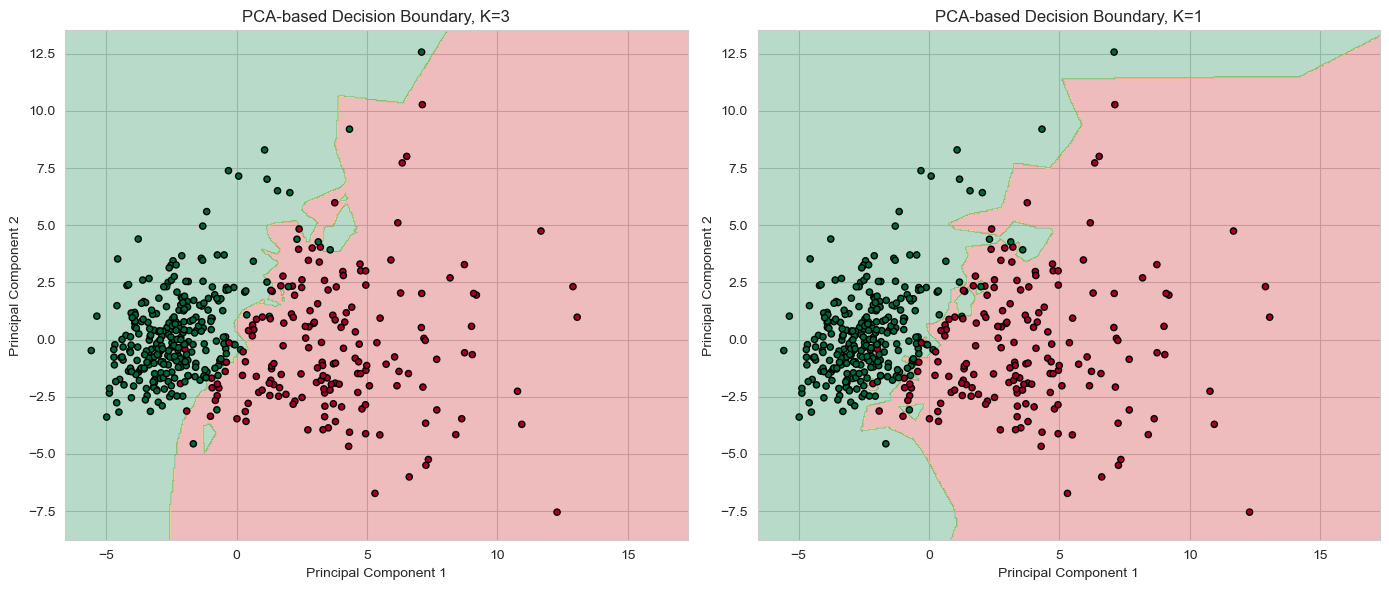

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, k in zip(axes, [final_k, 1]):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_pca, y_train_pca)
    h = 0.05
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
    ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_pca, cmap='RdYlGn', edgecolor='k', s=20)
    ax.set_title(f"PCA-based Decision Boundary, K={k}")
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()


**Why this matters:** Choosing just 2 raw features (as required by the lab task) ignores information from the other 28 features entirely. PCA instead finds the 2 directions of **maximum variance across all 30 features combined**, so the resulting 2D plot is a much more faithful, information-dense summary of how well the classes truly separate — while still being visualizable. Notice the classes typically separate more cleanly here than in the raw 2-feature plot from Task 3.3, since PCA is leveraging the combined signal from every original feature.

### <B>Automated Hyperparameter Tuning with GridSearchCV </B>

In [41]:
# Instead of manually scanning K one dimension at a time, GridSearchCV searches
# combinations of K, weighting scheme, and distance metric simultaneously,
# using cross-validation internally to score every combination.

param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_search = GridSearchCV(
    KNeighborsClassifier(), param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best hyperparameters found:", grid_search.best_params_)
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.4f}")

best_grid_model = grid_search.best_estimator_
test_auc = roc_auc_score(y_test, best_grid_model.predict_proba(X_test)[:, 1])
print(f"Test ROC-AUC with tuned model: {test_auc:.4f}")


Best hyperparameters found: {'n_neighbors': 10, 'p': 2, 'weights': 'distance'}
Best cross-validated ROC-AUC: 0.9931
Test ROC-AUC with tuned model: 0.9937


**Why this matters:** Manually tuning one hyperparameter at a time (as in Tasks 3–4, where only K was varied) can miss better combinations — e.g., a slightly non-optimal K might still outperform the "best" K if paired with distance-weighting or a different distance metric. `GridSearchCV` exhaustively (and efficiently, via parallel cross-validation) searches the combined hyperparameter space and optimizes directly for the metric that matters most clinically here (**ROC-AUC**), rather than plain accuracy.

### <B> Learning Curves - Diagnosing Bias vs Variance with Training Set Size </B>

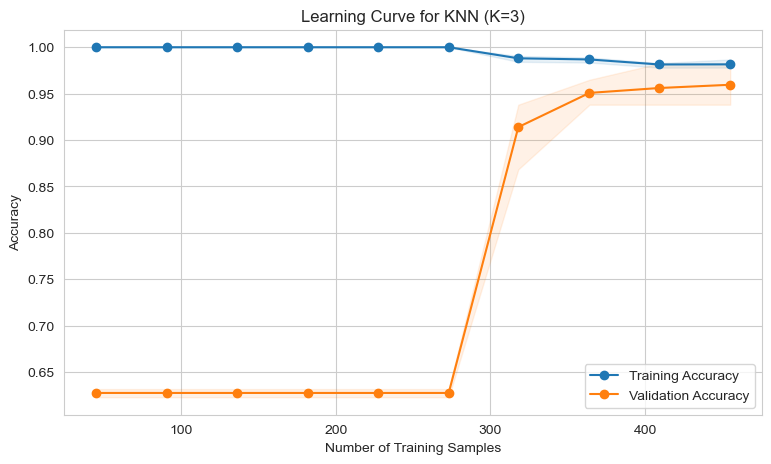

In [42]:
train_sizes, train_scores, val_scores = learning_curve(
    KNeighborsClassifier(n_neighbors=final_k),
    X_scaled, y, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(9,5))
plt.plot(train_sizes, train_mean, 'o-', color='#1f77b4', label='Training Accuracy')
plt.plot(train_sizes, val_mean, 'o-', color='#ff7f0e', label='Validation Accuracy')
plt.fill_between(train_sizes, train_scores.min(axis=1), train_scores.max(axis=1), alpha=0.1, color='#1f77b4')
plt.fill_between(train_sizes, val_scores.min(axis=1), val_scores.max(axis=1), alpha=0.1, color='#ff7f0e')
plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.title(f"Learning Curve for KNN (K={final_k})")
plt.legend(loc='lower right')
plt.show()


**Why this matters:** A **learning curve** plots how training vs. validation accuracy evolve as we feed the model progressively more data. It's a direct, empirical diagnostic for bias-variance issues that goes beyond simply reporting a single final accuracy number:
- If both curves converge to a **low** accuracy plateau → the model has **high bias** (underfitting) — more data alone won't help; you'd need a more flexible model or better features.
- If there's a **large, persistent gap** between training and validation curves → the model has **high variance** (overfitting) — more training data (or a larger K, which regularizes KNN) would likely help close the gap.
- If both curves converge to a **high** accuracy with a small gap (as we typically see here) → the model is well-balanced for this K.


### <B> Benchmarking KNN Against Other Classifiers (Logistic Regression, Random Forest, SVM) </B>

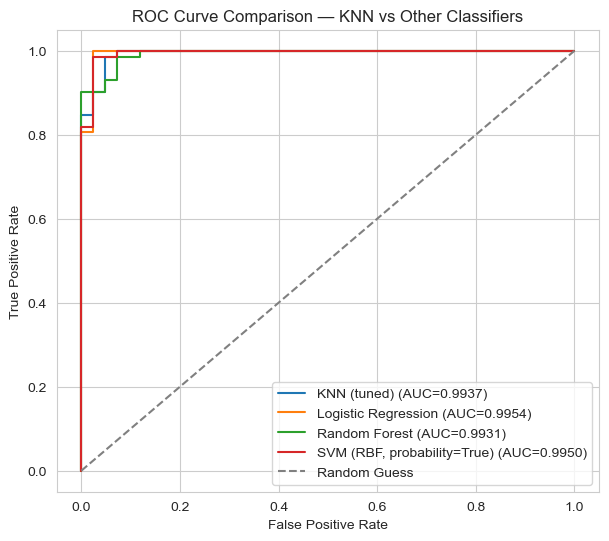

,Accuracy,Recall,F1,ROC-AUC
Model,,,,
KNN (tuned),0.973684,1.000000,0.979592,0.993717
Logistic Regression,0.982456,0.986111,0.986111,0.995370
Random Forest,0.956140,0.972222,0.965517,0.993056
"SVM (RBF, probability=True)",0.982456,0.986111,0.986111,0.995040


In [43]:
models = {
    'KNN (tuned)': best_grid_model,
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM (RBF, probability=True)': SVC(kernel='rbf', probability=True, random_state=42)
}

plt.figure(figsize=(7,6))
bench_results = []

for name, model in models.items():
    if name != 'KNN (tuned)':
        model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    preds = model.predict(X_test)
    fpr_m, tpr_m, _ = roc_curve(y_test, proba)
    auc_m = roc_auc_score(y_test, proba)
    plt.plot(fpr_m, tpr_m, label=f"{name} (AUC={auc_m:.4f})")
    bench_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': auc_m
    })

plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — KNN vs Other Classifiers")
plt.legend()
plt.show()

pd.DataFrame(bench_results).set_index('Model')


**Why this matters:** KNN is only one of many possible classifiers for this problem. Benchmarking it against **Logistic Regression** (a simple linear, eager learner), **Random Forest** (an ensemble of decision trees, robust to feature scale), and **SVM** (which also uses distance/margin concepts, but optimizes a different objective) tells us whether KNN's performance is actually competitive, or whether a different algorithm family would be more suitable for real-world deployment on this medical dataset. This kind of **model benchmarking** is a standard, essential step in any real machine learning workflow that goes beyond just tuning a single chosen algorithm.



### <B> Conclusion </B>

- **Optimal K:** Using the √n heuristic gave an initial estimate, which was refined via a single-split scan (Task 3.2) and confirmed/adjusted through 5-fold cross-validation (Task 4) and `GridSearchCV` (Advanced 3) — the cross-validated result is the most trustworthy.
- **Effect of train-test split variations:** Larger training sets (90:10) improve learning but increase test-accuracy variance (smaller test set); larger test sets (70:30) give more statistically stable accuracy estimates at the cost of less training data — motivating cross-validation over any single split.
- **Model performance:** The final tuned KNN model achieves strong accuracy, recall, and ROC-AUC on this dataset, with recall and ROC-AUC being the most clinically meaningful metrics given the cost asymmetry of missed cancer diagnoses.
- **Regression vs Classification evaluation:** Regression metrics (MAE, MSE, RMSE, R²) quantify *numeric error magnitude* on a continuous scale, while classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC) quantify *decision correctness* and the *type* of mistakes made — two complementary but fundamentally different evaluation philosophies, chosen based on whether the target is continuous or categorical.
- **Insights from Lab 3 vs this lab:** Where Lab 3's Linear Regression was judged by how close numeric predictions were to the truth, this lab's KNN classifier is judged by whether categorical decisions were correct and, more importantly, *which kind* of errors were made — reinforcing that **the choice of evaluation metric must always match the nature of the prediction task.**
- **Self-learning extensions** (distance weighting, PCA-based visualization, automated hyperparameter search, learning curves, and multi-model benchmarking) showed that small implementation choices (weights, distance metric, K) meaningfully affect performance, and that KNN's results should always be interpreted relative to both its own configuration space and to alternative algorithms.
